##TUGAS BESAR KECERDASAN MESIN  
Anggota:
- 2172013 - Raafi Khasha Brahmadito Haritsyah
- 2472007 - Richard Vincentius Christian Dinata
- 2472018 - Kevin Kornelius Martadinata

Imports

In [21]:
# --- INSTALASI LIBRARY WAJIB ---
!pip install tf2onnx onnx

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import os
import kagglehub

Load Dataset

In [22]:
# 1. Download otomatis versi terbaru dari Kaggle
path = kagglehub.dataset_download("patelris/who-health-dataset-43-indicators-200-countries")
print("Path to dataset files:", path)

# 2. Gabungkan path folder dengan nama file CSV spesifik
# Menggunakan os.path.join agar kompatibel di Windows maupun Linux/Mac
health_indicators_path = os.path.join(path, "health_indicators.csv")
metadata_path = os.path.join(path, "indicator_metadata.csv")

# 3. Baca file CSV ke dalam DataFrame pandas
df = pd.read_csv(health_indicators_path)
metadata = pd.read_csv(metadata_path)

print(f"\nSukses memuat data!")
print(f"Dimensi dataset awal: {df.shape}")
print("\nInformasi Kolom & Missing Values Awal:")
print(df.info())

Using Colab cache for faster access to the 'who-health-dataset-43-indicators-200-countries' dataset.
Path to dataset files: /kaggle/input/who-health-dataset-43-indicators-200-countries

Sukses memuat data!
Dimensi dataset awal: (5275, 48)

Informasi Kolom & Missing Values Awal:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5275 entries, 0 to 5274
Data columns (total 48 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   country_code                   5275 non-null   object 
 1   country_name                   5275 non-null   object 
 2   region                         5275 non-null   object 
 3   income_level                   5275 non-null   object 
 4   year                           5275 non-null   int64  
 5   population                     5275 non-null   float64
 6   population_growth              5274 non-null   float64
 7   urban_pct                      5275 non-null   float64
 8   life_expe

Exploratory Data Analysis (EDA)


> 5 Baris Pertama Data:


,country_code,country_name,region,income_level,year,population,population_growth,urban_pct,life_expectancy,life_expectancy_male,...,stunting_pct,wasting_pct,overweight_children_pct,undernourishment_pct,fertility_rate,adolescent_fertility,prenatal_care_pct,gdp_per_capita,gdp_per_capita_ppp,poverty_rate
0,ABW,Aruba,Latin America & Caribbean,High income,2000,90588.0,1.030817,65.354550,72.939,70.149,...,NaN,NaN,NaN,NaN,1.845,43.729,NaN,20681.023027,30245.706974,NaN
1,ABW,Aruba,Latin America & Caribbean,High income,2001,91439.0,0.935033,65.335114,73.044,70.251,...,NaN,NaN,NaN,NaN,1.813,40.463,NaN,20740.132583,31920.239073,NaN
2,ABW,Aruba,Latin America & Caribbean,High income,2002,92074.0,0.692052,65.282069,73.135,70.364,...,NaN,NaN,NaN,NaN,1.800,38.185,NaN,21307.248251,31888.508737,NaN
3,ABW,Aruba,Latin America & Caribbean,High income,2003,93128.0,1.138229,65.198292,73.236,70.488,...,NaN,NaN,NaN,NaN,1.808,37.807,NaN,21949.485996,32507.084315,NaN
4,ABW,Aruba,Latin America & Caribbean,High income,2004,95138.0,2.135358,65.088653,73.223,70.487,...,NaN,NaN,NaN,NaN,1.819,38.761,NaN,23700.631990,35059.273098,NaN



> Informasi Kolom & Missing Values Awal:


,Jumlah Missing Values
country_code,0
country_name,0
region,0
income_level,0
year,0
population,0
population_growth,1
urban_pct,0
life_expectancy,0
life_expectancy_male,0



> Menampilkan Distribusi Angka Harapan Hidup:


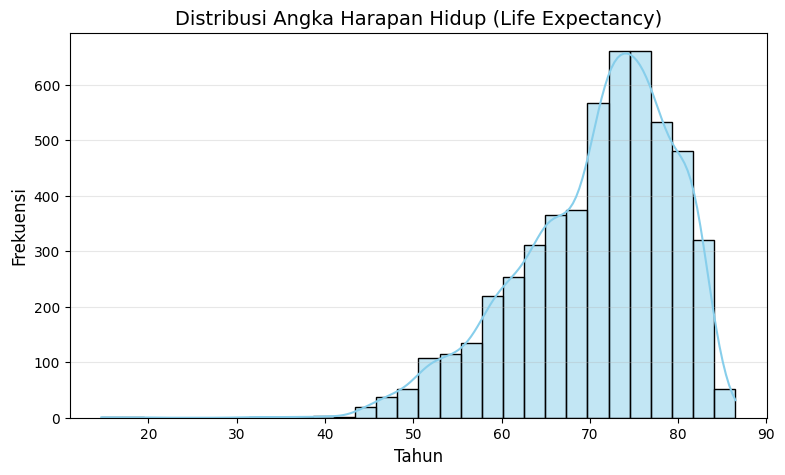


> Menampilkan Matriks Korelasi Fitur Kesehatan & Ekonomi:


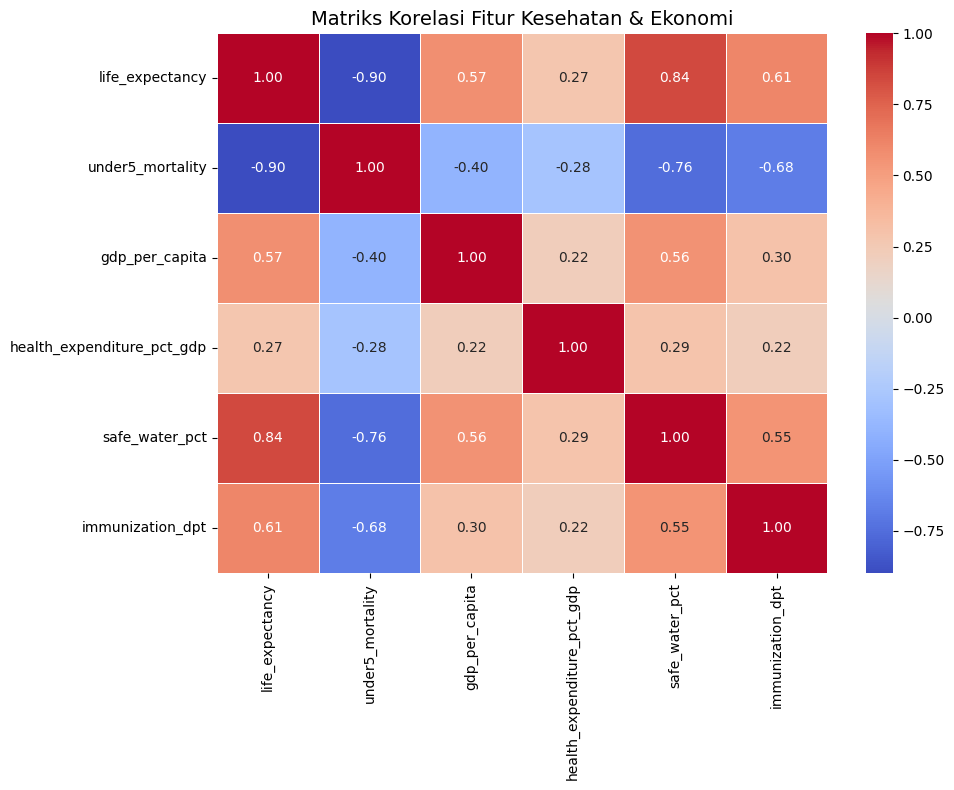

In [23]:
# Menampilkan 5 data pertama untuk inspeksi visual struktur tabel
print("\n> 5 Baris Pertama Data:")
display(df.head())

# Menampilkan informasi tipe data dan jumlah missing values awal
print("\n> Informasi Kolom & Missing Values Awal:")
display(df.isna().sum().to_frame(name='Jumlah Missing Values'))

# Visualisasi Distribusi Life Expectancy
print("\n> Menampilkan Distribusi Angka Harapan Hidup:")
plt.figure(figsize=(9, 5))
sns.histplot(df['life_expectancy'].dropna(), kde=True, color='skyblue', bins=30)
plt.title('Distribusi Angka Harapan Hidup (Life Expectancy)', fontsize=14)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

# Visualisasi Matriks Korelasi Fitur Numerik
print("\n> Menampilkan Matriks Korelasi Fitur Kesehatan & Ekonomi:")
plt.figure(figsize=(10, 8))
fitur_numerik = ['life_expectancy', 'under5_mortality', 'gdp_per_capita',
                 'health_expenditure_pct_gdp', 'safe_water_pct', 'immunization_dpt']
corr_matrix = df[fitur_numerik].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriks Korelasi Fitur Kesehatan & Ekonomi', fontsize=14)
plt.tight_layout()
plt.show()

Penanganan Misssing Values (Imputasi)

In [24]:
# Urutkan data berdasarkan negara dan tahun secara historis
df = df.sort_values(by=['country_name', 'year']).reset_index(drop=True)

# ---> PERBAIKAN: Hapus duplikasi data (Data Engineering)
df = df.drop_duplicates()

# Daftar semua fitur numerik yang memiliki missing values berdasarkan output EDA
fitur_diimputasi = [
    'population_growth', 'health_expenditure_pct_gdp', 'health_expenditure_per_capita',
    'physicians_per_1000', 'hospital_beds_per_1000', 'nurses_per_1000',
    'under5_mortality', 'neonatal_mortality', 'maternal_mortality',
    'tb_incidence', 'hiv_incidence', 'communicable_death_pct',
    'noncommunicable_death_pct', 'smoking_male', 'smoking_female',
    'obesity_pct', 'alcohol_per_capita', 'diabetes_pct',
    'safe_water_pct', 'sanitation_pct', 'handwashing_pct',
    'immunization_measles', 'immunization_dpt', 'immunization_bcg',
    'immunization_pol3', 'immunization_hib3', 'stunting_pct',
    'wasting_pct', 'overweight_children_pct', 'undernourishment_pct',
    'prenatal_care_pct', 'gdp_per_capita', 'gdp_per_capita_ppp', 'poverty_rate'
]

# Langkah A: Interpolasi Linier (Maju dan Mundur) berdasarkan tren waktu per negara
for fitur in fitur_diimputasi:
    df[fitur] = df.groupby('country_name')[fitur].transform(lambda x: x.interpolate(method='linear', limit_direction='both'))

# Langkah B: Regional Imputation (Jika satu negara bolong total, isi dengan median wilayah + tahun tersebut)
for fitur in fitur_diimputasi:
    df[fitur] = df.groupby(['region', 'year'])[fitur].transform(lambda x: x.fillna(x.median()))

# Langkah C: Pembersihan Total
for fitur in fitur_diimputasi:
    if df[fitur].isnull().sum() > 0:
        df[fitur] = df[fitur].fillna(df[fitur].median())
    if df[fitur].isnull().sum() > 0:
        df[fitur] = df[fitur].bfill().ffill()

# Langkah D: Jaminan Akhir
for fitur in fitur_diimputasi:
    if df[fitur].isnull().sum() > 0:
        df[fitur] = df[fitur].fillna(df[fitur].median())
    df[fitur] = df[fitur].fillna(0)

print("Jumlah missing values SETELAH pengecekan total:")
display(df[fitur_diimputasi].isnull().sum().to_frame(name='Sisa Missing Values'))


Jumlah missing values SETELAH pengecekan total:


,Sisa Missing Values
population_growth,0
health_expenditure_pct_gdp,0
health_expenditure_per_capita,0
physicians_per_1000,0
hospital_beds_per_1000,0
nurses_per_1000,0
under5_mortality,0
neonatal_mortality,0
maternal_mortality,0
tb_incidence,0



Rekayasa variabel Target (Klasifikasi Resiko)

In [25]:
# Membuat logika penentuan tingkat risiko kesehatan berdasarkan rubrik manual
# Kita gunakan median/kuartil dari data untuk menentukan batas objektif
low_life_exp = df['life_expectancy'].quantile(0.33)  # Batas bawah harapan hidup
high_mortality = df['under5_mortality'].quantile(0.66) # Batas atas kematian balita

def tentukan_risiko(row):
    # Risiko Tinggi: Harapan hidup rendah DAN mortalitas balita tinggi
    if row['life_expectancy'] < low_life_exp and row['under5_mortality'] > high_mortality:
        return 2  # 'Risiko Tinggi'
    # Risiko Rendah: Harapan hidup tinggi DAN mortalitas balita rendah
    elif row['life_expectancy'] >= df['life_expectancy'].quantile(0.66) and row['under5_mortality'] <= df['under5_mortality'].quantile(0.33):
        return 0  # 'Risiko Rendah'
    else:
        return 1  # 'Risiko Sedang'

df['target_risiko'] = df.apply(tentukan_risiko, axis=1)
print("Distribusi Target Risiko Kesehatan (0: Rendah, 1: Sedang, 2: Tinggi):")
print(df['target_risiko'].value_counts())
print("\n")

Distribusi Target Risiko Kesehatan (0: Rendah, 1: Sedang, 2: Tinggi):
target_risiko
1    2296
2    1579
0    1400
Name: count, dtype: int64




Normalisasi

In [26]:
# ---> PERBAIKAN: Fitur input (X) diperbarui HANYA fitur yang disetujui (tanpa membocorkan target)
fitur_model = ['gdp_per_capita', 'health_expenditure_pct_gdp', 'safe_water_pct', 'immunization_dpt'] 

# KITA TIDAK MELAKUKAN SCALING DI SINI UNTUK MENCEGAH DATA LEAKAGE!
# Scaling akan dilakukan setelah Train-Test Split agar model tidak mengintip data testing.

print("Fitur yang akan digunakan sebagai input (X):", fitur_model)

# Simpan dataset bersih
df.to_csv('clean_data.csv', index=False)
print("-> Sukses! File 'clean_data.csv' telah berhasil dibuat tanpa data leakage.")


Fitur yang akan digunakan sebagai input (X): ['gdp_per_capita', 'health_expenditure_pct_gdp', 'safe_water_pct', 'immunization_dpt']
-> Sukses! File 'clean_data.csv' telah berhasil dibuat tanpa data leakage.


Exploratory Data Analysis (EDA) Clean Data

Data bersih berhasil dimuat!
Jumlah baris: 5275, Jumlah kolom: 49


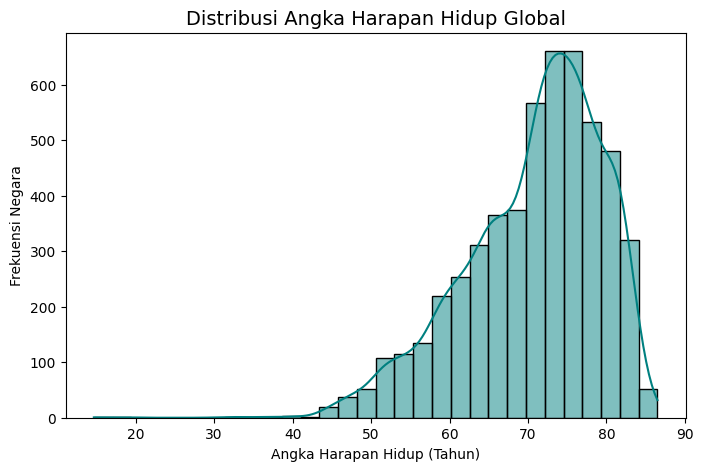

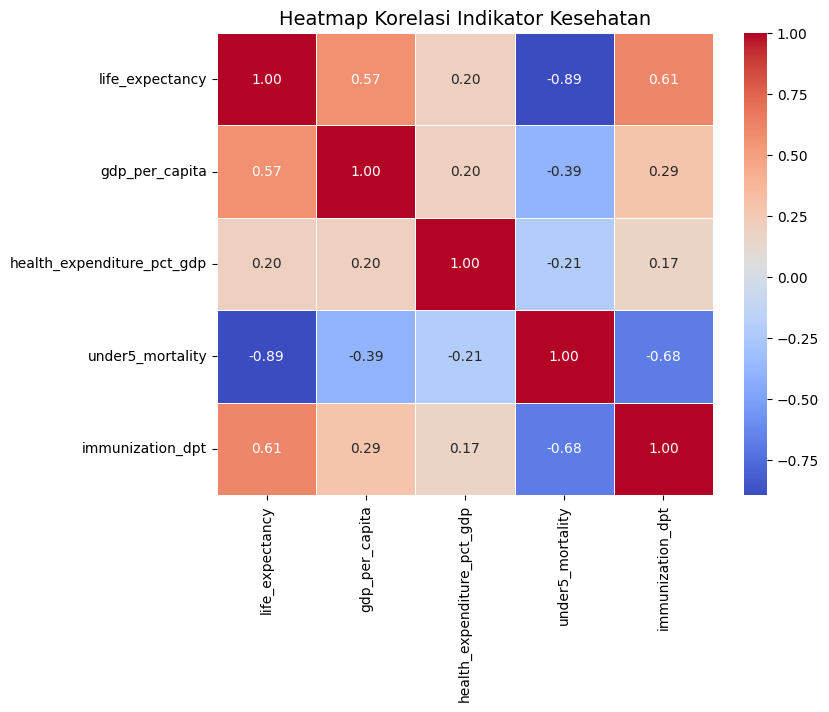

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Memuat Dataset yang sudah dibersihkan
df = pd.read_csv('clean_data.csv')
print("Data bersih berhasil dimuat!")
print(f"Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}")

# 2. Visualisasi EDA: Distribusi Angka Harapan Hidup Global
plt.figure(figsize=(8, 5))
sns.histplot(df['life_expectancy'].dropna(), bins=30, kde=True, color='teal')
plt.title('Distribusi Angka Harapan Hidup Global', fontsize=14)
plt.xlabel('Angka Harapan Hidup (Tahun)')
plt.ylabel('Frekuensi Negara')
plt.show()

# 3. Visualisasi EDA: Heatmap Korelasi Fitur Kesehatan
# Melihat hubungan antara ekonomi, kesehatan, dan kematian bayi
fitur_korelasi = ['life_expectancy', 'gdp_per_capita', 'health_expenditure_pct_gdp', 'under5_mortality', 'immunization_dpt']
plt.figure(figsize=(8, 6))
sns.heatmap(df[fitur_korelasi].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Indikator Kesehatan', fontsize=14)
plt.show()

Persiapan Data Traditional ML

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

fitur_ml = ['gdp_per_capita', 'health_expenditure_pct_gdp', 'safe_water_pct', 'immunization_dpt']

df_ml = df.dropna(subset=fitur_ml + ['target_risiko']).copy()

# X adalah data fitur, y adalah target prediksi (Tingkat Risiko: 0, 1, 2)
X = df_ml[fitur_ml]
y = df_ml['target_risiko']

# ---> PERBAIKAN FAIRNESS: Membagi data 80:20
# WAJIB: random_state=42 dan stratify=y agar proporsi data testing-training sangat seimbang!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jumlah data untuk Training: {X_train.shape[0]} baris")
print(f"Jumlah data untuk Testing: {X_test.shape[0]} baris")

# ---> PERBAIKAN DATA LEAKAGE: Scaling dilakukan SETELAH Split
scaler = MinMaxScaler()
# fit_transform HANYA pada X_train (Belajar)
X_train_scaled = scaler.fit_transform(X_train)
# transform saja pada X_test (Ujian)
X_test_scaled = scaler.transform(X_test)
print("Scaling selesai dengan aman!")


Jumlah data untuk Training: 4220 baris
Jumlah data untuk Testing: 1055 baris
Scaling selesai dengan aman!


Training Model & Evaluasi Metrik

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV

# 1. Menyiapkan Algoritma Tradisional
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Support Vector Machine (SVM)": SVC(random_state=42)
}

# ---> PERBAIKAN: Hyperparameter Tuning pada Random Forest
print("="*40)
print("--- Melakukan Hyperparameter Tuning pada Random Forest ---")
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

best_rf = grid_search.best_estimator_
print(f"Parameter Terbaik Random Forest: {grid_search.best_params_}")
models["Random Forest (Tuned)"] = best_rf

# 3. Melatih dan Mengevaluasi Masing-masing Model
for nama_model, model in models.items():
    print(f"\n" + "="*40)
    print(f"--- Evaluasi Model: {nama_model} ---")
    print("="*40)

    if nama_model != "Random Forest (Tuned)":
        model.fit(X_train_scaled, y_train)

    # Prediksi WAJIB menggunakan X_test_scaled
    y_pred = model.predict(X_test_scaled)

    # Metrik Evaluasi Lengkap
    print(classification_report(y_test, y_pred, zero_division=0))

    if nama_model == "Random Forest (Tuned)":
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
        disp.plot(cmap='Blues')
        plt.title(f'Confusion Matrix - {nama_model}')
        plt.show()


--- Melakukan Hyperparameter Tuning pada Random Forest ---


## Analisis Error

In [ ]:
# ==========================================================
# --- ANALISIS ERROR: FALSE POSITIVE & FALSE NEGATIVE ---
# ==========================================================

# Mendapatkan ulang prediksi dari model Random Forest Ter-Tuning
model_rf = models["Random Forest (Tuned)"]
y_pred_rf = model_rf.predict(X_test_scaled)

# Membuat DataFrame perbandingan
df_error = X_test.copy() 
df_error['Aktual'] = y_test
df_error['Prediksi'] = y_pred_rf

# Asumsi Tingkat Risiko:
# 2 = Risiko Tinggi, 1 = Risiko Sedang, 0 = Risiko Rendah 

kasus_fn = df_error[(df_error['Aktual'] == 2) & (df_error['Prediksi'] < 2)]
kasus_fp = df_error[(df_error['Aktual'] < 2) & (df_error['Prediksi'] == 2)]

print("="*50)
print("HASIL ANALISIS ERROR (Berdasarkan Konteks Kesehatan Dunia)")
print("="*50)
print(f"Jumlah Total Data Ujian (Testing): {len(y_test)}")
print(f"-> False Negative (Gagal Deteksi Risiko Tinggi) : {len(kasus_fn)} kasus (SANGAT BERBAHAYA)")
print(f"-> False Positive (Salah Deteksi / Alarm Palsu) : {len(kasus_fp)} kasus (Pemborosan Anggaran)")


## Deep Learning (LSTM Model)

This section will cover preparing the data for an LSTM model, defining and training the LSTM, and finally exporting the trained model to ONNX format.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# ---> PERBAIKAN FAIRNESS EVALUATION (Data Wajib Sama Persis dengan RF)
# Karena LSTM membutuhkan input 3D [samples, time_steps, features], kita reshape data 2D ML Tradisional menjadi 3D.
# time_steps = 1 (memprediksi risiko tahun/baris itu juga)

X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# Mengubah target kategori 0, 1, 2 menjadi One-Hot Encoding
y_train_categorical = to_categorical(y_train, num_classes=3)
y_test_categorical = to_categorical(y_test, num_classes=3)

print("Data LSTM Siap dan 100% IDENTIK dengan data Traditional ML!")
print(f"Bentuk Input X_train_lstm: {X_train_lstm.shape}")


Shape of X (features): (4220, 5, 5)
Shape of y (target): (4220, 3)


Now, let's define, compile, and train the LSTM model. We'll split the data into training and testing sets.

In [ ]:
# ---> PERBAIKAN: Arsitektur KLASIFIKASI LSTM (activation tanh & EarlyStopping)
model = Sequential([
    # Wajib menggunakan activation='tanh' (bukan relu) untuk mencegah exploding gradients di RNN/LSTM
    LSTM(64, activation='tanh', input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='tanh'),
    Dropout(0.2),
    # Layer Output HARUS 3 neuron dengan softmax karena ini Klasifikasi Kelas Risiko (0,1,2)
    Dense(3, activation='softmax') 
])

# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Menerapkan EarlyStopping untuk menghindari Overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
print("Memulai Training Klasifikasi LSTM...")
history = model.fit(
    X_train_lstm, 
    y_train_categorical, 
    epochs=50, 
    batch_size=32, 
    validation_split=0.2, 
    callbacks=[early_stop],
    verbose=1
)

# Evaluate the model
loss, accuracy = model.evaluate(X_test_lstm, y_test_categorical, verbose=0)
print(f"\n✅ Evaluasi Selesai! Test Accuracy LSTM: {accuracy:.4f}")


Task 1 - Setup Library Tambahan

In [ ]:
# ==========================================================
# --- EKSPOR FINAL KLASIFIKASI LSTM KE ONNX ---
# ==========================================================

# 1. Install library
!pip install tf2onnx onnx

import tf2onnx
import onnx
import tensorflow as tf

# 2. Simpan model KLASIFIKASI sebagai "SavedModel"
saved_model_path = 'lstm_classifier_saved_model'
model.export(saved_model_path)
print(f"1. Model Klasifikasi berhasil diekspor ke folder: {saved_model_path}")

# 3. Konversi ke ONNX
onnx_model_path = 'lstm_risk_classifier_final.onnx'
print("2. Memulai konversi ke ONNX...")
!python -m tf2onnx.convert --saved-model {saved_model_path} --output {onnx_model_path} --opset 15

# 4. Verifikasi file ONNX
onnx_model = onnx.load(onnx_model_path)
onnx.checker.check_model(onnx_model)
print(f"3. ✅ MANTAP! File ONNX final untuk KLASIFIKASI RISIKO siap dicolok ke Agent AI Anda: {onnx_model_path}")
